# Get code lists

In [1]:
import pandas as pd

df = pd.read_parquet("../data/validation.parquet")
human_codes = df[df["label"] == 0]["code"].tolist()
ai_codes = df[df["label"] == 1]["code"].tolist()

# Configure features

In [2]:
import re
import numpy as np

def extract_top_features(code):
    if not code or not code.strip():
        return {
            "blank_line": 0.0,
            "whitespace": 0.0,
            "comment": 0.0,
            "pr_lines": 0.0,
            "paragraph_spaces": 0.0,
            "pr_per_line": 0.0,
            "standard_comment": 0.0
        }

    # Feat 1: blank lines ratio
    lines = code.strip().split('\n')
    total_lines = len(lines)
    
    blank_lines = sum(1 for line in lines if not line.strip())
    blank_line_ratio = blank_lines / total_lines if total_lines > 0 else 0.0

    # Feat 2: whitespace ratio
    whitespaces = [l.count(' ') + 4 * l.count('\t') for l in lines]
    mean_whitespaces = np.mean(whitespaces)
    whitespace_ratio = np.std(whitespaces) / mean_whitespaces if mean_whitespaces > 0 else 0.0

    # Feat 3: comment ratio
    # Find '//' and '#'
    comment_lines = sum(1 for line in lines if re.search(r'(?://|#)', line))
    comment_ratio = comment_lines / total_lines if total_lines > 0 else 0.0

    # Feat 4: paragraph
    paragraphs = [pr for pr in code.split('\n\n') if len(pr) > 0]
    pr_lines = [pr.count('\n') for pr in paragraphs]
    std_pr_lines = np.std(pr_lines) 
    pr_lines_ratio = std_pr_lines / (np.mean(pr_lines) + std_pr_lines) if std_pr_lines > 0 else 0.0

    # Feat 5: paragraph_spaces
    pr_spaces = [pr.count(' ') for pr in paragraphs]
    std_pr_spaces = np.std(pr_spaces) 
    pr_spaces_ratio = std_pr_spaces / (np.mean(pr_spaces) + std_pr_spaces) if std_pr_spaces > 0 else 0.0

    # Feat 6: paragraphs and comments
    comment_per_pr = comment_lines / (len(paragraphs) + comment_lines) if comment_lines > 0 else 0.0

    # Feat 7: Standard comment
    _RE_UNIVERSAL_MARKER = re.compile(r"(?:#|//|--|%)(.?)")
    comments = _RE_UNIVERSAL_MARKER.findall(code)
    if not comments:
        standard_comment_ratio = 0.0
    else:
        is_spaced = np.array([c.isspace() for c in comments])
        standard_comment_ratio = np.mean(is_spaced)

    return {
        "blank_line": round(blank_line_ratio, 4),
        "whitespace": round(whitespace_ratio, 4),
        "comment": round(comment_ratio, 4),
        "pr_lines": round(pr_lines_ratio, 4),
        "paragraph_spaces": round(pr_spaces_ratio, 4),
        "comment_per_pr": round(comment_per_pr, 4),
        "standard_comment": round(standard_comment_ratio, 4)
    }

def features_statistics(codes, return_lists=False):
    feats_dict = {}

    for code in codes:
        feats = extract_top_features(code)
        for k, v in feats.items():
            feats_dict.setdefault(k, []).append(v)

    if return_lists:
        return list(feats_dict.values())

    statistics = {
        k: [round(np.mean(v), 3), round(np.std(v), 3)]
        for k, v in feats_dict.items()
    }

    return statistics

# Diagrams

### Extract features 

In [3]:
human_feat_lists = features_statistics(human_codes[10000:12000], return_lists=True)
ai_feat_lists = features_statistics(ai_codes[10000:12000], return_lists=True)

### 1D Diagram (1 feature)

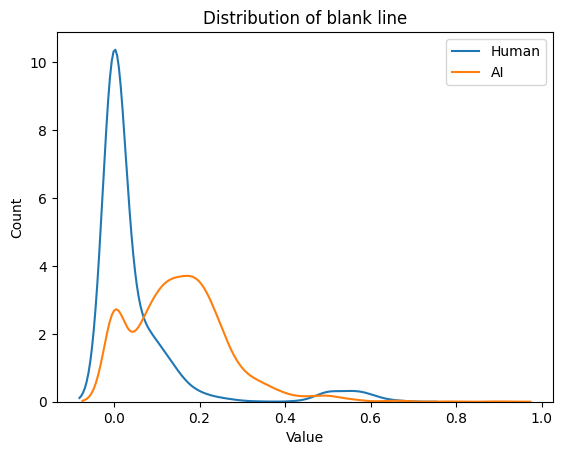

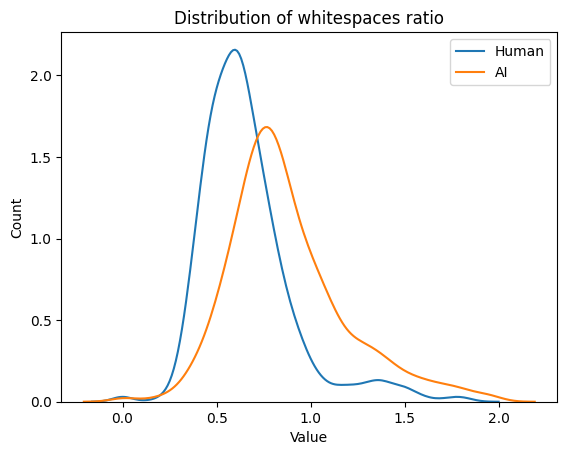

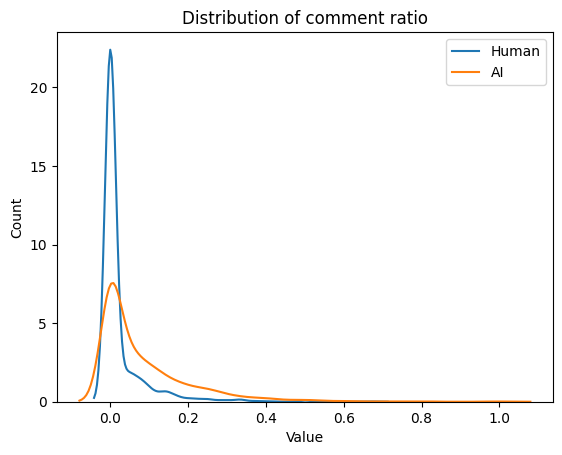

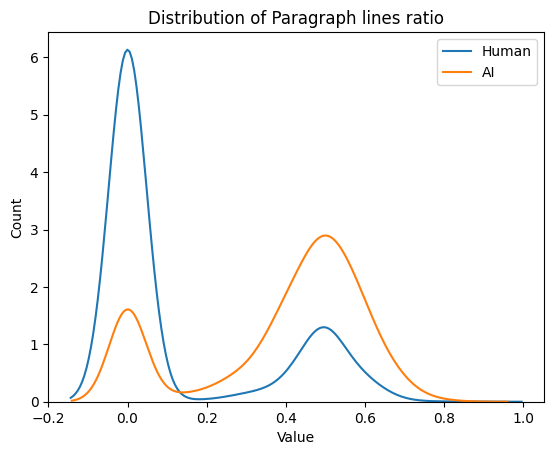

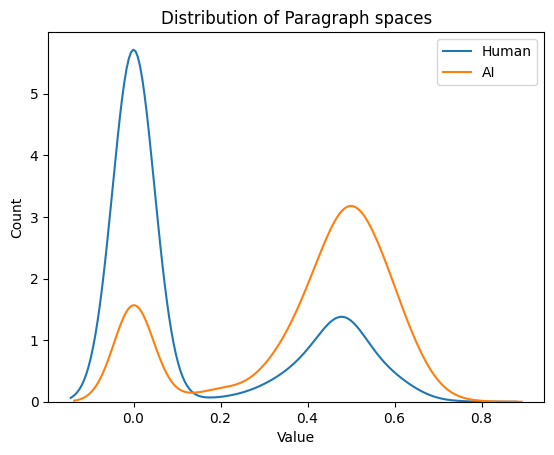

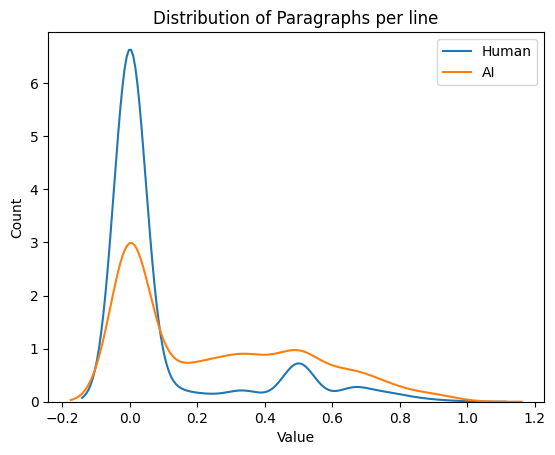

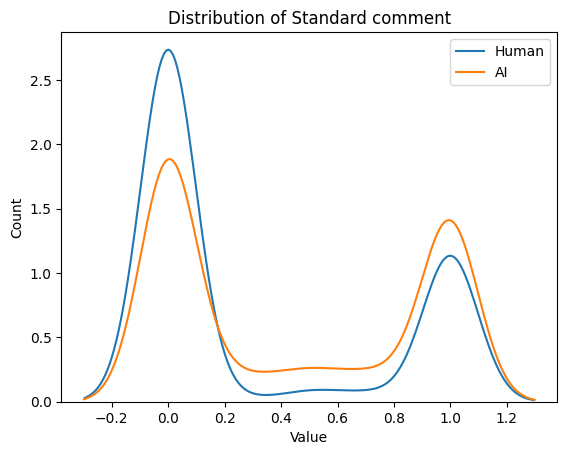

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

feat_names = ["blank line", "whitespaces ratio", "comment ratio", "Paragraph lines ratio", "Paragraph spaces", "Paragraphs per line", "Standard comment"]
feats = [0, 1, 2, 3, 4, 5, 6] # Choose the features to visualize (feature's index in range [0, 6])

for feat_idx in feats:
    human = [x for x in human_feat_lists[feat_idx] if x < 2]
    ai = [x for x in ai_feat_lists[feat_idx] if x < 2]

    plt.figure()

    sns.kdeplot(human, label="Human")
    sns.kdeplot(ai, label="AI")

    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.title("Distribution of " + feat_names[feat_idx])
    plt.legend()
    plt.show()


### 2D diagram (2 features)

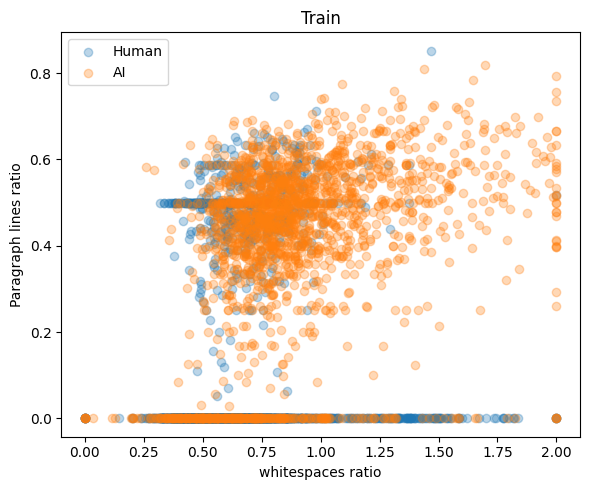

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Choose 2 features to visualize
idx1, idx2 = 1, 3 

# Train
train_human1 = np.clip(human_feat_lists[idx1], 0, 2)
train_human2 = np.clip(human_feat_lists[idx2], 0, 2)
train_ai1 = np.clip(ai_feat_lists[idx1], 0, 2)
train_ai2 = np.clip(ai_feat_lists[idx2], 0, 2)

# Plot
plt.figure(figsize=(6, 5))

plt.scatter(train_human1, train_human2, alpha=0.3, label="Human")
plt.scatter(train_ai1, train_ai2, alpha=0.3, label="AI")

plt.xlabel(feat_names[idx1])
plt.ylabel(feat_names[idx2])
plt.title("Train")
plt.legend()

plt.tight_layout()
plt.show()

### 3D diagram

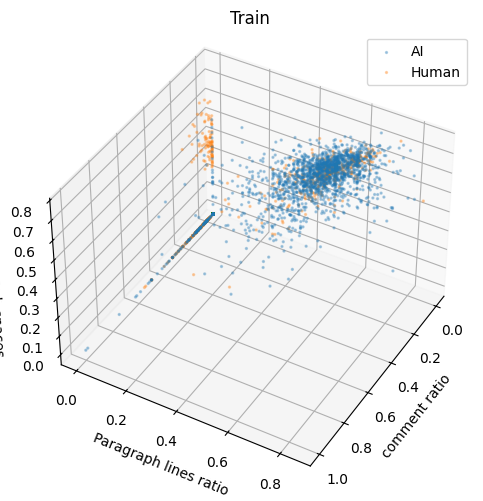

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Choose 3 features to visualize
idx1, idx2, idx3 = 2, 3, 4

# Train data
train_human1 = np.clip(human_feat_lists[idx1], 0, 2)
train_human2 = np.clip(human_feat_lists[idx2], 0, 2)
train_human3 = np.clip(human_feat_lists[idx3], 0, 2)
train_ai1 = np.clip(ai_feat_lists[idx1], 0, 2)
train_ai2 = np.clip(ai_feat_lists[idx2], 0, 2)
train_ai3 = np.clip(ai_feat_lists[idx3], 0, 2)

# Plot
fig = plt.figure(figsize=(12, 5))

ax = fig.add_subplot(1, 2, 1, projection='3d')

# -- Plot Train
ax.scatter(train_ai1, train_ai2, train_ai3, alpha=0.3, s=2, label="AI")
ax.scatter(train_human1, train_human2, train_human3, alpha=0.3, s=2, label="Human")
ax.set_xlabel(feat_names[idx1])
ax.set_ylabel(feat_names[idx2])
ax.set_zlabel(feat_names[idx3])
ax.set_title("Train")
ax.view_init(elev=40, azim=30)
ax.legend()

plt.tight_layout()
plt.show()
